# Pruebas de integración — SmartLight + Keithley + Láser (Vigo)

Ejecuta las celdas **en orden**.

| Sección | Qué hace |
|---------|----------|
| 1 | Conexión SSH + medir_loop.py |
| 2 | Comprobación de polarización (por puerto) |
| 3 | Keithley solo — ejemplo de práctica |
| 4 | Integración reducida Keithley + chip |
| 5 | Barrido completo de voltaje (Keithley) |
| 6 | Medida real — 500 retos a 1550nm + barrido de longitud de onda (láser) |
| 7 | Cierre limpio |
| 8 | Guardar resultados |


## Imports comunes
Ejecutar siempre primero.

In [7]:
import Meas_classes as ms
import paramiko
import json, time, getpass
import numpy as np
import pandas as pd
import pyvisa as visa
import math

In [15]:
def shutdown_tls(tls, TLSslot, hold_wavelength_nm=None, turn_off=True):
    """Exit sweep mode, optionally hold a wavelength, and turn laser output off."""
    tls.write("sour"+TLSslot+":wav:swe 0")
    tls.query("*OPC?")
    if hold_wavelength_nm is not None:
        tls.write("sour"+TLSslot+":wav %.9fnm" % float(hold_wavelength_nm))
        tls.query("*OPC?")
    if turn_off:
        tls.write("sour"+TLSslot+":pow:stat 0")
        tls.write("outp"+TLSslot+":stat 0")
        tls.query("*OPC?")
        print("Laser output turned off.")


def turnon_tls(tls, TLSslot, hold_wavelength_nm=None,TLSpower=10, turn_on=True):
    max_wavelenght=1640
    min_wavelenght=1490
    
    if (hold_wavelength_nm <  str(min_wavelenght)): 
        print("!!!Warning¡¡¡ , laser wavelenght below  min wavelenght possible, Set to 1490")
        hold_wavelength_nm="1490"
    if (hold_wavelength_nm >  str(max_wavelenght)): 
        print("!!!Warning¡¡¡, laser wavelenght over  max wavelenght possible, Set to 1640")
        hold_wavelength_nm="1640"
        
    """Exit sweep mode, optionally hold a wavelength, and turn laser output off."""
    tls.write("sour"+TLSslot+":wav:swe 0")
    tls.query("*OPC?")
    
    
    if hold_wavelength_nm is not None:
        tls.write("sour"+TLSslot+":wav %.9fnm" % float(hold_wavelength_nm))
        tls.query("*OPC?")
        
    tls.write("sour"+TLSslot+":wav:swe:pmax? "+hold_wavelength_nm+"nm,"+hold_wavelength_nm+"nm")
   
    SWPpower = 10*math.log10(float(tls.read()))
    # print(SWPpower)
    if SWPpower < float(TLSpower):
        TLSpower = str(SWPpower)
        print("!!!Warning¡¡¡, Over maxpower possible, power changed to  "+str(TLSpower)+"  dbm"  )
    tls.write("sour"+TLSslot+":pow "+str(TLSpower)+"dbm")        
        
    # print("sour"+TLSslot+":pow "+str(TLSpower)+"dbm"  )
        
    if turn_on:
        tls.write("sour"+TLSslot+":pow:stat 1")
        tls.write("outp"+TLSslot+":stat 1")
        while(tls.query("*OPC?") == 0):
            print("Laser no listo")
        else:
            return True


def TLSconnect(TLSaddr="",TLSslot=""):
    
    tls =  None


    #Open Connection
    rm = visa.ResourceManager('C:\\Program Files\\IVI Foundation\\VISA\\Win64\\ktvisa\\ktbin\\visa32.dll')

    
    #Open Visa Connections
    tls = rm.open_resource(TLSaddr)
    # if PMaddr == TLSaddr:
    #     pm = tls
    # else:
    #     pm = rm.open_resource(PMaddr)

    #Set Timeout - 5 seconds
    tls.timeout = 10000 
    #*IDN? - Query Instrumnet ID
    tls_id = tls.query("*IDN?")
    print("TLS_idn: " + str(tls_id))
    
    return tls
    
def inst_err(inst, max_reads=20):
    ## Query for Errors
    error_list = []
    for _ in range(max_reads):
        inst.write(":SYSTem:ERRor?")
        error = inst.read()
        error_list.append(error)
        if 'No error' in error:
            break
    return error_list

## Sección 1 — Conexión SSH + medir_loop.py
Comprueba que el SmartLight responde correctamente a un comando de prueba.

In [9]:
PASSWORD = '35a45f40a90d240ad2a9bf0f48e358c6'

ssh = paramiko.SSHClient()
ssh.set_missing_host_key_policy(paramiko.AutoAddPolicy())
ssh.connect('172.19.61.219', username='smartlight', password=PASSWORD)

stdin, stdout, stderr = ssh.exec_command(
    'cd /home/smartlight/Oxel && /home/smartlight/.venvs/ipronics/bin/python medir_loop_po_est.py'
)

def medir_remoto(inport, n_retos):
    cmd = {'inport': inport, 'n_retos': n_retos}
    stdin.write(json.dumps(cmd) + '\n')
    stdin.flush()
    return json.loads(stdout.readline())

print('✓ SSH conectado y medir_loop.py lanzado. Esperando a que el chip calibre...')

✓ SSH conectado y medir_loop.py lanzado. Esperando a que el chip calibre...


In [10]:
hilo_monitor = threading.Thread(target=monitor_stderr, args=(stderr,), daemon=True)
hilo_monitor.start()

NameError: name 'threading' is not defined

In [ ]:
# Prueba con muy pocos retos para validar rápido
res_test = medir_remoto(inport=1, n_retos=2)
print(json.dumps(res_test, indent=2)[:1000])

Si ves un JSON con `'powers'` → **Sección 1 OK**.

Si sale `'error'`, ejecuta `print(stderr.read().decode())` en una celda nueva para ver el traceback completo.

## Sección 2 — Comprobación de polarización

**Ejecutar cada vez que cambies el puerto de entrada (INPORT).**

Flujo:
1. Mover físicamente la fibra al nuevo puerto
2. `preparar_externo(...)` → mirar el medidor analógico, ajustar la polarización a mano
3. `comprobar_polarizacion(...)` → verificar que los fotodetectores internos también ven bien la señal

In [16]:
def preparar_externo(inport, outport_prueba):
    """Configura el chip para que el medidor analógico externo pueda leer
    la salida. Después de llamar a esto, ajusta la polarización a mano
    mirando el medidor analógico conectado físicamente al puerto."""
    cmd = {'accion': 'preparar_externo', 'inport': inport, 'outport': outport_prueba}
    stdin.write(json.dumps(cmd) + '\n')
    stdin.flush()
    res = json.loads(stdout.readline())

    if 'error' in res:
        print(f'⚠ Error: {res["error"]}')
        return None

    print(f'✓ {res["status"]}')
    return res


def comprobar_polarizacion(inport, outport_prueba):
    """Lee las potencias con los fotodetectores internos, una vez ya
    ajustada la polarización a mano con el medidor analógico."""
    cmd = {'accion': 'polarizacion', 'inport': inport, 'outport': outport_prueba}
    stdin.write(json.dumps(cmd) + '\n')
    stdin.flush()
    res = json.loads(stdout.readline())

    if 'error' in res:
        print(f'⚠ Error: {res["error"]}')
        return None

    powers = {int(k): v for k, v in res['powers'].items()}

    print(f'Entrada: puerto {inport}')
    print(f'{"Puerto salida":>14}  {"Potencia (dBm)":>15}')
    print('-' * 32)
    for puerto, potencia in sorted(powers.items()):
        barra = '█' * int((potencia + 50) / 2) if potencia > -50 else ''
        print(f'{puerto:>14}  {potencia:>15.4f}  {barra}')

    return powers
def setear_reto(inport, reto_idx=0):
    """Programa la ruta + aplica el reto UNA SOLA VEZ. Llamar antes
    de un barrido rápido donde el reto se mantiene constante."""
    cmd = {'accion': 'setear_reto', 'inport': inport, 'reto_idx': reto_idx}
    stdin.write(json.dumps(cmd) + '\n')
    stdin.flush()
    res = json.loads(stdout.readline())
    if 'error' in res:
        print(f'⚠ Error: {res["error"]}')
        return None
    print(f'✓ {res["status"]}')
    return res


def medida_rapida():
    """Mide usando la ruta+reto ya fijados por setear_reto().
    No reprograma nada — solo lee potencias."""
    cmd = {'accion': 'medida_rapida'}
    stdin.write(json.dumps(cmd) + '\n')
    stdin.flush()
    return json.loads(stdout.readline())

In [17]:
tls=TLSconnect(TLSaddr="TCPIP0::172.19.61.230::inst0::INSTR",TLSslot=0)

TLS_idn: Keysight Technologies,N7778C,DE59800602,V3.520



In [7]:
if (turnon_tls(tls, TLSslot="0", hold_wavelength_nm="1550", TLSpower="10",turn_on=True)  ):
        print("Laser set")

Laser set


In [18]:
# ── Cambia esto cada vez que muevas la fibra a un nuevo puerto ────────
INPORT         = 21
PRUEBA_OUTPORT = 3

preparar_externo(INPORT, PRUEBA_OUTPORT)
# → ahora mira el medidor analógico y ajusta la polarización a mano

✓ listo — mide con el medidor analógico y ajusta la polarización


{'accion': 'preparar_externo',
 'inport': 21,
 'outport_prueba': 3,
 'status': 'listo — mide con el medidor analógico y ajusta la polarización'}

In [16]:
print(stderr.read().decode())

In [21]:
# Una vez ajustada la polarización a mano, comprobar con fotodetectores internos


LONGITUDES = ["1550", "1560", "1570"]
for l in LONGITUDES:
    if (turnon_tls(tls, TLSslot="0", hold_wavelength_nm=l, TLSpower="10",turn_on=True)  ):
        print("Laser set")
    comprobar_polarizacion(INPORT, PRUEBA_OUTPORT)


Laser set
Entrada: puerto 21
 Puerto salida   Potencia (dBm)
--------------------------------
             0         -44.9634  ██
             1         -43.8720  ███
             2         -43.0005  ███
             3          -4.3974  ██████████████████████
             4         -40.4771  ████
             5         -43.6118  ███
             6         -40.3800  ████
             7         -39.6123  █████
             8         -39.9033  █████
             9         -40.7557  ████
            10         -42.2014  ███
            11         -40.5764  ████
            12         -43.0005  ███
            13         -43.8720  ███
            14         -41.3431  ████
            15         -39.7762  █████
            16         -41.1384  ████
            17         -42.7038  ███
            18         -41.0816  ████
            19         -40.8084  ████
            20         -40.3086  ████
            34         -42.5036  ███
            35         -42.5036  ███
            36        

## Sección 3 — Keithley solo (ejemplo de práctica)
Sin tocar el SmartLight. Verifica que cambia de voltaje y lee bien.

In [ ]:
WAVELENGTHS = np.arange(1550, 1550.501, 0.005)
N_RETOS_BARRIDO = 1
resultados_barrido = []
puerto = INPORT  # Cambia esto si mueves la fibra a otro puerto

for l in WAVELENGTHS:
    if (turnon_tls(tls, TLSslot="0", hold_wavelength_nm=f"{l}", TLSpower="10",turn_on=True)  ):
        print("Laser set")

    res = medir_remoto(inport=puerto, n_retos=N_RETOS_BARRIDO)
    if 'error' in res:
        print(f'⚠ λ={wl:.2f} nm → {res["error"]}')
        continue

    resultados_barrido.append({'wavelength': float(l), 'powers': res['powers']})

Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set
Laser set


In [57]:
import time

WAVELENGTHS = np.arange(1550, 1550.805, 0.005)
puerto = INPORT  # Cambia esto si mueves la fibra a otro puerto

# Fijar la ruta + el reto UNA SOLA VEZ, antes del bucle
setear_reto(inport=puerto, reto_idx=0)

resultados_barrido = []
tiempos = []   # para medir dónde se va el tiempo

for i, l in enumerate(WAVELENGTHS):
    t_inicio = time.time()

    t0 = time.time()
    laser_ok = turnon_tls(tls, TLSslot="0", hold_wavelength_nm=f"{l}", TLSpower="10", turn_on=True)
    t_laser = time.time() - t0
    if laser_ok:
        print(f"[{i+1}/{len(WAVELENGTHS)}] λ={l:.3f} nm — Laser set")

    t0 = time.time()
    res = medida_rapida()
    t_medida = time.time() - t0

    t_total = time.time() - t_inicio

    if 'error' in res:
        print(f'⚠ λ={l:.3f} nm → {res["error"]}')
        continue

    resultados_barrido.append({'wavelength': float(l), 'powers': res['powers']})
    tiempos.append({
        'wavelength': float(l),
        't_laser_s':  round(t_laser, 4),
        't_medida_s': round(t_medida, 4),
        't_total_s':  round(t_total, 4),
    })

    print(f"    λ={l:.3f} nm  →  láser: {t_laser:.3f}s  |  medida: {t_medida:.3f}s  |  total: {t_total:.3f}s")

# ── RESUMEN DE TIEMPOS ───────────────────────────────────────────────────
import pandas as pd
df_tiempos = pd.DataFrame(tiempos)

print(f"\n{'='*55}")
print(f"RESUMEN DE TIEMPOS — {len(df_tiempos)} puntos")
print(f"{'='*55}")
print(f"Tiempo medio láser:   {df_tiempos['t_laser_s'].mean():.4f} s")
print(f"Tiempo medio medida:  {df_tiempos['t_medida_s'].mean():.4f} s")
print(f"Tiempo medio total:   {df_tiempos['t_total_s'].mean():.4f} s")
print(f"Tiempo total barrido: {df_tiempos['t_total_s'].sum():.2f} s")
print(f"\nCuello de botella: "
      f"{'LÁSER' if df_tiempos['t_laser_s'].mean() > df_tiempos['t_medida_s'].mean() else 'MEDIDA (chip)'}")

✓ reto fijado — usa medida_rapida para medir sin reprogramar
[1/162] λ=1550.000 nm — Laser set
    λ=1550.000 nm  →  láser: 0.607s  |  medida: 0.008s  |  total: 0.616s
[2/162] λ=1550.005 nm — Laser set
    λ=1550.005 nm  →  láser: 0.242s  |  medida: 0.007s  |  total: 0.249s
[3/162] λ=1550.010 nm — Laser set
    λ=1550.010 nm  →  láser: 0.231s  |  medida: 0.007s  |  total: 0.239s
[4/162] λ=1550.015 nm — Laser set
    λ=1550.015 nm  →  láser: 0.302s  |  medida: 0.007s  |  total: 0.309s
[5/162] λ=1550.020 nm — Laser set
    λ=1550.020 nm  →  láser: 0.224s  |  medida: 0.007s  |  total: 0.231s
[6/162] λ=1550.025 nm — Laser set
    λ=1550.025 nm  →  láser: 0.233s  |  medida: 0.008s  |  total: 0.241s
[7/162] λ=1550.030 nm — Laser set
    λ=1550.030 nm  →  láser: 0.223s  |  medida: 0.007s  |  total: 0.231s
[8/162] λ=1550.035 nm — Laser set
    λ=1550.035 nm  →  láser: 0.228s  |  medida: 0.007s  |  total: 0.235s
[9/162] λ=1550.040 nm — Laser set
    λ=1550.040 nm  →  láser: 0.228s  |  medida: 0

In [59]:
import time
import pandas as pd

WAVELENGTHS = np.arange(1550, 1550.805, 0.005)
puerto = INPORT

setear_reto(inport=puerto, reto_idx=0)

resultados_barrido = []
tiempos = []

t_inicio_total = time.time()

for i, l in enumerate(WAVELENGTHS):
    t_inicio = time.time()

    t0 = time.time()
    turnon_tls(tls, TLSslot="0", hold_wavelength_nm=f"{l}", TLSpower="10", turn_on=True)
    t_laser = time.time() - t0

    t0 = time.time()
    res = medida_rapida()
    t_medida = time.time() - t0

    t_total = time.time() - t_inicio

    if 'error' in res:
        print(f'⚠ λ={l:.3f} nm → {res["error"]}')
        continue

    resultados_barrido.append({'wavelength': float(l), 'powers': res['powers']})
    tiempos.append({'wavelength': float(l), 't_laser_s': t_laser,
                     't_medida_s': t_medida, 't_total_s': t_total})

    # Solo imprime cada 20 puntos, no en cada vuelta
    if (i + 1) % 20 == 0 or i == len(WAVELENGTHS) - 1:
        print(f"[{i+1}/{len(WAVELENGTHS)}] λ={l:.3f} nm  "
              f"(láser: {t_laser*1000:.0f}ms, medida: {t_medida*1000:.0f}ms)")

t_total_real = time.time() - t_inicio_total

df_tiempos = pd.DataFrame(tiempos)
print(f"\n{'='*55}")
print(f"RESUMEN — {len(df_tiempos)} puntos")
print(f"{'='*55}")
print(f"Tiempo medio láser:   {df_tiempos['t_laser_s'].mean()*1000:.1f} ms")
print(f"Tiempo medio medida:  {df_tiempos['t_medida_s'].mean()*1000:.1f} ms")
print(f"Tiempo real total:    {t_total_real:.2f} s")
print(f"Cuello de botella:    "
      f"{'LÁSER' if df_tiempos['t_laser_s'].mean() > df_tiempos['t_medida_s'].mean() else 'MEDIDA (chip/SSH)'}")

✓ reto fijado — usa medida_rapida para medir sin reprogramar
[20/162] λ=1550.095 nm  (láser: 99ms, medida: 14ms)
[40/162] λ=1550.195 nm  (láser: 98ms, medida: 14ms)
[60/162] λ=1550.295 nm  (láser: 107ms, medida: 15ms)
[80/162] λ=1550.395 nm  (láser: 100ms, medida: 14ms)
[100/162] λ=1550.495 nm  (láser: 104ms, medida: 7ms)
[120/162] λ=1550.595 nm  (láser: 86ms, medida: 7ms)
[140/162] λ=1550.695 nm  (láser: 99ms, medida: 13ms)
[160/162] λ=1550.795 nm  (láser: 101ms, medida: 14ms)
[162/162] λ=1550.805 nm  (láser: 100ms, medida: 15ms)

RESUMEN — 162 puntos
Tiempo medio láser:   126.1 ms
Tiempo medio medida:  12.5 ms
Tiempo real total:    22.45 s
Cuello de botella:    LÁSER


In [53]:
import pandas as pd
import matplotlib.pyplot as plt

# ── Construir DataFrame: filas = longitud de onda, columnas = puertos ──
filas = []
for entrada in resultados_barrido:
    wl = entrada['wavelength']
    # powers es una lista (n_retos medidas); con N_RETOS_BARRIDO=1 solo hay una
    powers_dict = entrada['powers'][0]
    fila = {'wavelength': wl}
    fila.update({int(k): v for k, v in powers_dict.items()})
    filas.append(fila)

df_barrido = pd.DataFrame(filas).set_index('wavelength')
df_barrido = df_barrido[sorted(df_barrido.columns)]

print(f"Shape: {df_barrido.shape}  (longitudes de onda x puertos)")
df_barrido.head()

KeyError: 0

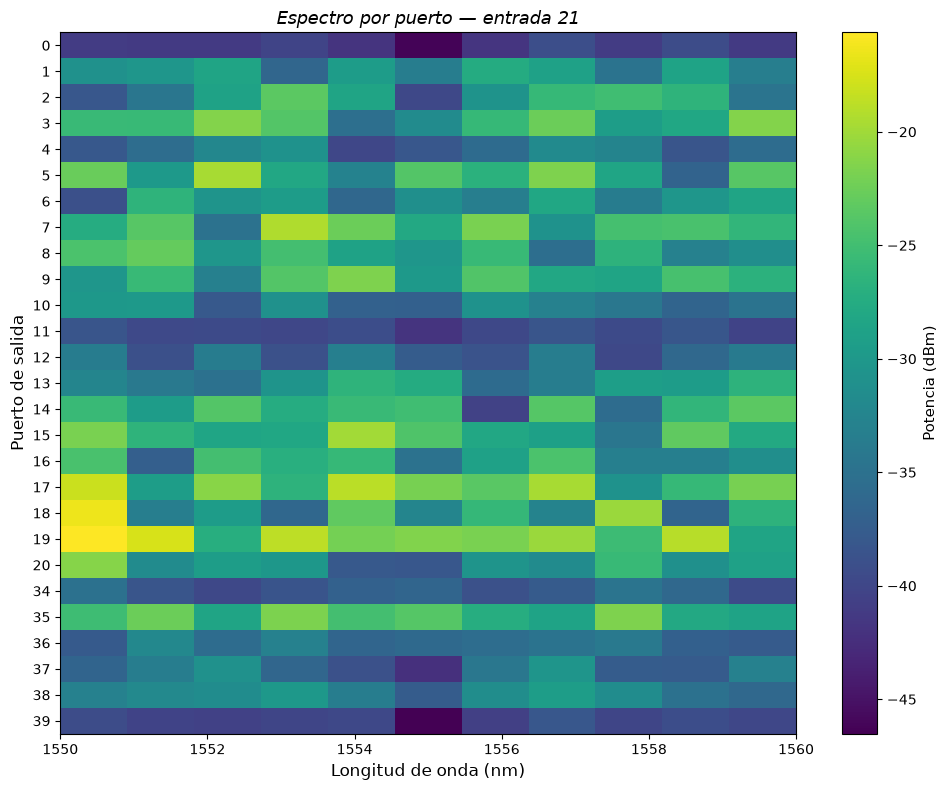

In [28]:
# ── ALTERNATIVA: heatmap puerto x longitud de onda ──────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(df_barrido.T.values, aspect='auto', cmap='viridis',
               extent=[df_barrido.index.min(), df_barrido.index.max(),
                       len(df_barrido.columns), 0])

ax.set_yticks(np.arange(len(df_barrido.columns)) + 0.5)
ax.set_yticklabels(df_barrido.columns)
ax.set_xlabel('Longitud de onda (nm)', fontsize=12)
ax.set_ylabel('Puerto de salida', fontsize=12)
ax.set_title(f'Espectro por puerto — entrada {INPORT}', fontsize=13, fontstyle='italic')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Potencia (dBm)', fontsize=11)

plt.tight_layout()
plt.show()

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

PUERTOS_INTERES = [0, 39, 11, 7, 9]

# ── Construir DataFrame largo: wavelength, puerto, reto_idx, power ──────
filas = []
for entrada in resultados_barrido:
    wl = entrada['wavelength']
    for reto_idx, powers_dict in enumerate(entrada['powers']):
        for puerto_str, potencia in powers_dict.items():
            puerto = int(puerto_str)
            if puerto in PUERTOS_INTERES:
                filas.append({
                    'wavelength': wl,
                    'puerto': puerto,
                    'reto_idx': reto_idx,
                    'power': potencia,
                })

df_largo = pd.DataFrame(filas)
df_largo.head(10)

AttributeError: 'str' object has no attribute 'items'

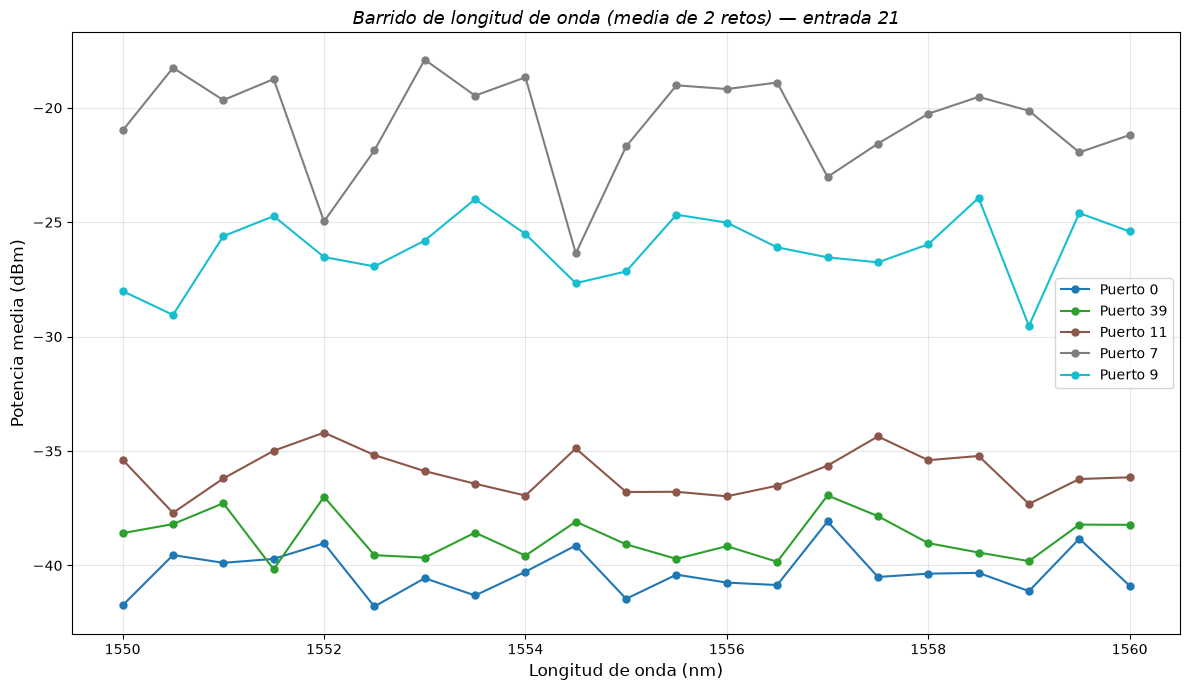

In [35]:
# ── ALTERNATIVA: media de los 2 retos por longitud de onda ─────────────
df_media = df_largo.groupby(['wavelength', 'puerto'])['power'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 7))
colores = plt.cm.tab10(np.linspace(0, 1, len(PUERTOS_INTERES)))

for color, puerto in zip(colores, PUERTOS_INTERES):
    sub = df_media[df_media['puerto'] == puerto].sort_values('wavelength')
    ax.plot(sub['wavelength'], sub['power'],
            marker='o', markersize=5, linewidth=1.5,
            color=color, label=f'Puerto {puerto}')

ax.set_xlabel('Longitud de onda (nm)', fontsize=12)
ax.set_ylabel('Potencia media (dBm)', fontsize=12)
ax.set_title(f'Barrido de longitud de onda (media de {N_RETOS_BARRIDO} retos) — entrada {INPORT}',
             fontsize=13, fontstyle='italic')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

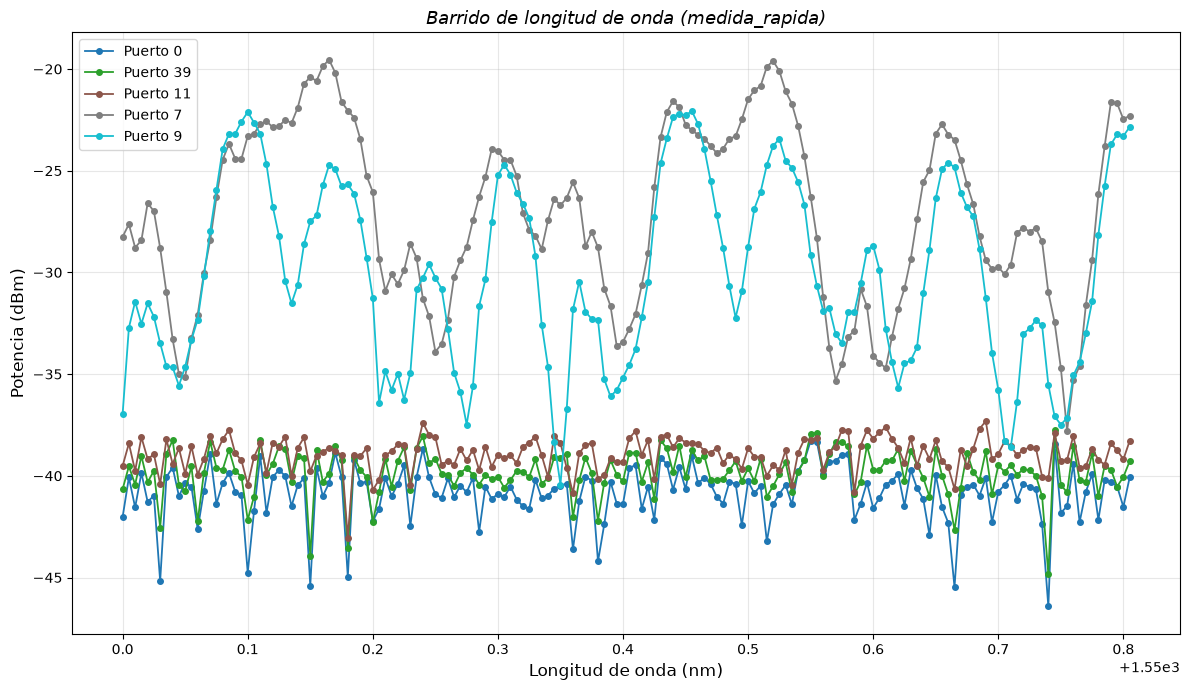

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

PUERTOS_INTERES = [0, 39, 11, 7, 9]

filas = []
for entrada in resultados_barrido:
    wl = entrada['wavelength']
    powers_dict = entrada['powers']   # ← ya es un dict directo, sin lista ni enumerate
    for puerto_str, potencia in powers_dict.items():
        puerto = int(puerto_str)
        if puerto in PUERTOS_INTERES:
            filas.append({
                'wavelength': wl,
                'puerto': puerto,
                'power': potencia,
            })

df_largo = pd.DataFrame(filas)

fig, ax = plt.subplots(figsize=(12, 7))
colores = plt.cm.tab10(np.linspace(0, 1, len(PUERTOS_INTERES)))

for color, puerto in zip(colores, PUERTOS_INTERES):
    sub = df_largo[df_largo['puerto'] == puerto].sort_values('wavelength')
    ax.plot(sub['wavelength'], sub['power'],
            marker='o', markersize=4, linewidth=1.3,
            color=color, label=f'Puerto {puerto}')

ax.set_xlabel('Longitud de onda (nm)', fontsize=12)
ax.set_ylabel('Potencia (dBm)', fontsize=12)
ax.set_title('Barrido de longitud de onda (medida_rapida)', fontsize=13, fontstyle='italic')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
keithley = ms.Keithley('20', 'GPIB0', 0.0011, -3)
keithley.set_keithley_for_meas_current()
keithley.on_keithley_fixed_volt()

In [ ]:
VOLTAJES_TEST = [1, 3, 5]

for v in VOLTAJES_TEST:
    keithley.volt_source = v
    keithley.on_keithley_fixed_volt()
    time.sleep(0.3)
    V_medido, I_medido = keithley.read_keithley()
    print(f'V={v:.2f} V  →  V_medido={V_medido:.4f} V,  I={I_medido:.4f} mA')

keithley.off_keithley_volt()
print('\n✓ Sección 3 completada')

## Sección 4 — Integración reducida (Keithley + chip)
3 voltajes × 2 retos.

In [ ]:
keithley.on_keithley_fixed_volt()

VOLTAJES_REDUCIDO = [1, 3, 5]
INPORT_TEST = 1
N_RETOS_TEST = 2

resultados_test = []

for v in VOLTAJES_REDUCIDO:
    keithley.volt_source = v
    keithley.on_keithley_fixed_volt()
    time.sleep(0.3)

    V_medido, I_medido = keithley.read_keithley()
    res_chip = medir_remoto(inport=INPORT_TEST, n_retos=N_RETOS_TEST)

    if 'error' in res_chip:
        print(f'⚠ V={v:.2f} V → error SmartLight: {res_chip["error"]}')
        continue

    resultados_test.append({
        'voltaje_programado': v,
        'voltaje_medido':     V_medido,
        'corriente_mA':       I_medido,
        'powers':             res_chip['powers'],
    })

    print(f'V={v:.2f} V  →  V_medido={V_medido:.4f} V,  '
          f'I={I_medido:.4f} mA,  {res_chip["n_medidos"]} retos medidos')

print(f'\n✓ Sección 4 completada — {len(resultados_test)} puntos')

## Sección 5 — Barrido completo de voltaje (Keithley)
Ejecutar solo cuando las secciones 1-4 hayan funcionado correctamente.

In [ ]:
VOLTAJES    = np.linspace(1, 5, 9)   # ajusta tu rango real
INPORT_KEITHLEY = 1
N_RETOS_KEITHLEY = 5

resultados_keithley = []

keithley.on_keithley_fixed_volt()

for v in VOLTAJES:
    keithley.volt_source = v
    keithley.on_keithley_fixed_volt()
    time.sleep(0.3)

    V_medido, I_medido = keithley.read_keithley()
    res_chip = medir_remoto(inport=INPORT_KEITHLEY, n_retos=N_RETOS_KEITHLEY)

    if 'error' in res_chip:
        print(f'⚠ V={v:.2f} V → error SmartLight: {res_chip["error"]}')
        continue

    resultados_keithley.append({
        'voltaje_programado': v,
        'voltaje_medido':     V_medido,
        'corriente_mA':       I_medido,
        'powers':             res_chip['powers'],
    })

    print(f'V={v:.2f} V  →  V_medido={V_medido:.4f} V,  '
          f'I={I_medido:.4f} mA,  {res_chip["n_medidos"]} retos medidos')

## Sección 6 — Medida real: 500 retos a 1550nm + barrido de longitud de onda (láser)

**Antes de ejecutar:** completa los parámetros del láser en la celda siguiente.
Si dejas algún valor en `None`, la celda de conexión lanzará un error claro
en vez de fallar de forma confusa más adelante.

In [ ]:
# ── PARÁMETROS DEL LÁSER — RELLENAR ANTES DE CONECTAR ──────────────────

POWER_LASER_DBM    = 11   # ej. 0.0

WL_BASE            = 1550.0   # longitud de onda de la medida estándar (nm)
N_RETOS_BASE       = 500      # retos de la medida estándar

N_RETOS_BARRIDO    = None   # ej. 50   — retos por paso del barrido
WL_INICIO          = None   # ej. 1530.0
WL_FIN             = None   # ej. 1570.0
WL_PASO_NM         = None   # ej. 1.0

INPORT_LASER       = 21     # puerto a medir con el láser

_faltan = [nombre for nombre, val in {
    'GPIB_ID_LASER': GPIB_ID_LASER, 'POWER_LASER_DBM': POWER_LASER_DBM,
    'N_RETOS_BARRIDO': N_RETOS_BARRIDO, 'WL_INICIO': WL_INICIO,
    'WL_FIN': WL_FIN, 'WL_PASO_NM': WL_PASO_NM,
}.items() if val is None]

if _faltan:
    print(f'⚠ Faltan por rellenar: {_faltan}')
else:
    WAVELENGTHS = np.arange(WL_INICIO, WL_FIN + WL_PASO_NM, WL_PASO_NM)
    print(f'✓ Parámetros completos. Barrido: {len(WAVELENGTHS)} puntos '
          f'de {WL_INICIO} a {WL_FIN} nm cada {WL_PASO_NM} nm')

NameError: name 'GPIB_ID_LASER' is not defined

In [ ]:
# Ver qué recursos VISA detecta para localizar el láser
import pyvisa as visa
rm_temp = visa.ResourceManager()
print(rm_temp.list_resources())

In [ ]:
# ── CONECTAR LÁSER (Laser_TL17) ────────────────────────────────────────
assert GPIB_ID_LASER is not None, 'Falta GPIB_ID_LASER'
assert POWER_LASER_DBM is not None, 'Falta POWER_LASER_DBM'

laser = ms.Laser_TL17(
    gpib_id=GPIB_ID_LASER,
    gpib_address=GPIB_ADDRESS_LASER,
    power=POWER_LASER_DBM,
    wl=WL_BASE,
)
laser.set_power_laser()
laser.set_wl_laser()
laser.on_laser()
time.sleep(1.0)
print(f'✓ Láser encendido a {WL_BASE} nm, {POWER_LASER_DBM} dBm')

In [11]:
import threading

def monitor_stderr(stderr_channel):
    """Lee stderr línea a línea en un hilo aparte y la imprime en vivo,
    sin bloquear la celda principal que espera la respuesta en stdout."""
    for line in iter(stderr_channel.readline, ''):
        if line:
            print(f'[SmartLight] {line.strip()}')

# Lanzar el monitor en background ANTES de llamar a medir_remoto()
hilo_monitor = threading.Thread(target=monitor_stderr, args=(stderr,), daemon=True)
hilo_monitor.start()

[SmartLight] Conectando al chip...
[SmartLight] ✓ Chip conectado y calibrado.
[SmartLight] Listo. Esperando comandos...


In [24]:
# ── PARÁMETROS DEL EXPERIMENTO — RELLENAR ANTES DEL BUCLE AUTOMÁTICO ────
import numpy as np

# Puertos de la malla
ACTIVE_PORTS = list(range(0, 22)) + list(range(34, 40))   # 28 puertos

# Polarización
PRUEBA_OUTPORT = 3        # puerto de salida por defecto para ajustar polarización

# Medida estándar (base)
WL_BASE        = 1550.0   # longitud de onda fija para la medida base (nm)
N_RETOS_BASE   = 200      # nº de retos a medir en la medida base

# Barrido de longitud de onda
WL_INICIO       = 1550.0
WL_FIN          = 1550.5
WL_PASO_NM      = 0.003
WAVELENGTHS     = np.arange(WL_INICIO, WL_FIN + WL_PASO_NM, WL_PASO_NM)
N_RETOS_BARRIDO = 25      # retos por punto del barrido (con medir_remoto)

print(f'✓ Variables definidas')
print(f'  Puertos activos:        {len(ACTIVE_PORTS)}')
print(f'  Puerto polarización:    {PRUEBA_OUTPORT}')
print(f'  Medida base:            {N_RETOS_BASE} retos a {WL_BASE} nm')
print(f'  Barrido λ:              {len(WAVELENGTHS)} puntos, '
      f'{WL_INICIO}–{WL_FIN} nm cada {WL_PASO_NM} nm')

✓ Variables definidas
  Puertos activos:        28
  Puerto polarización:    3
  Medida base:            200 retos a 1550.0 nm
  Barrido λ:              168 puntos, 1550.0–1550.5 nm cada 0.003 nm


In [26]:
# ── RECORRIDO AUTOMÁTICO POR PUERTOS ───────────────────────────────────
import glob, re, time
import pandas as pd

# Preguntar por qué puerto empezar
_puerto_inicio = input('¿Por qué puerto quieres empezar? (Enter = orden normal, 0-21/34-39): ').strip()

if _puerto_inicio:
    puerto_inicio = int(_puerto_inicio)
    PUERTOS_A_MEDIR = [puerto_inicio] + [p for p in ACTIVE_PORTS if p != puerto_inicio]
    print(f'✓ Empezando por el puerto {puerto_inicio}, luego el resto en orden')
else:
    PUERTOS_A_MEDIR = ACTIVE_PORTS
    print('✓ Orden normal de puertos')

# Repoblar PUERTOS_HECHOS mirando qué archivos ya existen en disco
PUERTOS_HECHOS = []
for fname in glob.glob('combinado_port*.json'):
    m = re.search(r'port(\d+)\.json$', fname)
    if m:
        PUERTOS_HECHOS.append(int(m.group(1)))
PUERTOS_HECHOS = sorted(set(PUERTOS_HECHOS))
if PUERTOS_HECHOS:
    print(f'✓ Puertos ya medidos (detectados en disco): {PUERTOS_HECHOS}')
else:
    print('No hay puertos medidos todavía — empezando de cero')

for puerto in PUERTOS_A_MEDIR:
    if puerto in PUERTOS_HECHOS:
        continue

    print(f'\n{"="*50}\nPUERTO {puerto}\n{"="*50}')
    input(f'Conecta la fibra al puerto {puerto} y pulsa Enter...')

    # Puerto de salida para polarización — normalmente el mismo, pero
    # cambiable puerto a puerto si hace falta (Enter = mantener el de antes)
    _outport_str = input(f'Puerto de salida para polarización (Enter = {PRUEBA_OUTPORT}): ').strip()
    outport_actual = int(_outport_str) if _outport_str else PRUEBA_OUTPORT

    # 1. Preparar modo externo y ajustar polarización a mano
    preparar_externo(puerto, outport_actual)
    turnon_tls(tls, TLSslot="0", hold_wavelength_nm=f"{WL_BASE}", TLSpower="11", turn_on=True)
    input('Ajusta la polarización con el medidor analógico y pulsa Enter...')

    # 2. Comprobar con fotodetectores internos
    comprobar_polarizacion(puerto, outport_actual)
    continuar = input('¿Polarización OK? (Enter para continuar, "r" para repetir el puerto) ')
    if continuar.strip().lower() == 'r':
        continue   # repite el mismo puerto sin marcarlo como hecho

    # 3. Medida combinada: para los primeros N_RETOS_BARRIDO retos se hace
    #    barrido completo de λ (incluye 1550nm como punto); para el resto
    #    de retos hasta N_RETOS_BASE, solo se mide en 1550nm
    resultados_combinados = []   # {'reto_idx', 'wavelength', 'powers'}
    tiempos = []
    t0_total = time.time()

    for reto_idx in range(N_RETOS_BASE):

        # Fijar este reto UNA VEZ
        setear_reto(inport=puerto, reto_idx=reto_idx)

        if reto_idx < N_RETOS_BARRIDO:
            # ── Barrido completo de λ para este reto ──
            for i, wl in enumerate(WAVELENGTHS):
                t0 = time.time()
                turnon_tls(tls, TLSslot="0", hold_wavelength_nm=f"{wl}", TLSpower="11", turn_on=True)
                t_laser = time.time() - t0

                t0 = time.time()
                res = medida_rapida()
                t_medida = time.time() - t0

                if 'error' in res:
                    print(f'⚠ reto {reto_idx}, λ={wl:.3f} nm → {res["error"]}')
                    continue

                resultados_combinados.append({
                    'reto_idx':   reto_idx,
                    'wavelength': float(wl),
                    'powers':     res['powers'],
                })
                tiempos.append({'reto_idx': reto_idx, 'wavelength': float(wl),
                                 't_laser_s': t_laser, 't_medida_s': t_medida})

            print(f'  ✓ Reto {reto_idx+1}/{N_RETOS_BASE} — barrido completo '
                  f'({len(WAVELENGTHS)} puntos λ)')

        else:
            # ── Solo medir en 1550nm ──
            t0 = time.time()
            turnon_tls(tls, TLSslot="0", hold_wavelength_nm=f"{WL_BASE}", TLSpower="11", turn_on=True)
            t_laser = time.time() - t0

            t0 = time.time()
            res = medida_rapida()
            t_medida = time.time() - t0

            if 'error' in res:
                print(f'⚠ reto {reto_idx} → {res["error"]}')
                continue

            resultados_combinados.append({
                'reto_idx':   reto_idx,
                'wavelength': WL_BASE,
                'powers':     res['powers'],
            })
            tiempos.append({'reto_idx': reto_idx, 'wavelength': WL_BASE,
                             't_laser_s': t_laser, 't_medida_s': t_medida})

            if (reto_idx + 1) % 50 == 0 or reto_idx == N_RETOS_BASE - 1:
                print(f'  ✓ Reto {reto_idx+1}/{N_RETOS_BASE} — solo 1550nm')

    t_total = time.time() - t0_total

    fname_combinado = f'combinado_port{puerto:02d}.json'
    with open(fname_combinado, 'w') as f:
        json.dump(resultados_combinados, f, indent=2)

    df_t = pd.DataFrame(tiempos)
    print(f'✓ {len(resultados_combinados)} medidas guardadas → {fname_combinado}')
    print(f'  Tiempo total puerto: {t_total:.1f}s ({t_total/60:.1f} min)')
    print(f'  Láser medio: {df_t["t_laser_s"].mean()*1000:.0f}ms  '
          f'| Medida media: {df_t["t_medida_s"].mean()*1000:.0f}ms')

    # 4. Marcar puerto como hecho
    PUERTOS_HECHOS.append(puerto)
    print(f'\n✓✓ Puerto {puerto} completado ({len(PUERTOS_HECHOS)}/{len(PUERTOS_A_MEDIR)})')

print(f'\n{"="*50}\nSESIÓN COMPLETA — {len(PUERTOS_HECHOS)} puertos medidos\n{"="*50}')
print(f'Puertos hechos:      {PUERTOS_HECHOS}')
print(f'Puertos pendientes:  {[p for p in PUERTOS_A_MEDIR if p not in PUERTOS_HECHOS]}')


✓ Empezando por el puerto 9, luego el resto en orden
✓ Puertos ya medidos (detectados en disco): [0, 1, 2, 3, 4, 5, 6, 7, 8]

PUERTO 9
✓ listo — mide con el medidor analógico y ajusta la polarización
!!!Warning¡¡¡, Over maxpower possible, power changed to  10.838193851715715  dbm
Entrada: puerto 9
 Puerto salida   Potencia (dBm)
--------------------------------
             0         -34.4077  ███████
             1         -37.1704  ██████
             2          -2.7678  ███████████████████████
             3         -33.0712  ████████
             4         -35.8051  ███████
             5         -35.0259  ███████
             6         -31.8847  █████████
             7         -28.3524  ██████████
             8         -35.0964  ███████
            10         -34.9291  ███████
            11         -38.6432  █████
            12         -39.5723  █████
            13         -40.6269  ████
            14         -38.0292  █████
            15         -38.5008  █████
           

Puerto de entrada: 21
Puertos de salida: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 34, 35, 36, 37, 38, 39]
Retos medidos:     10

Shape de la matriz: (10, 27)  (retos x puertos de salida)


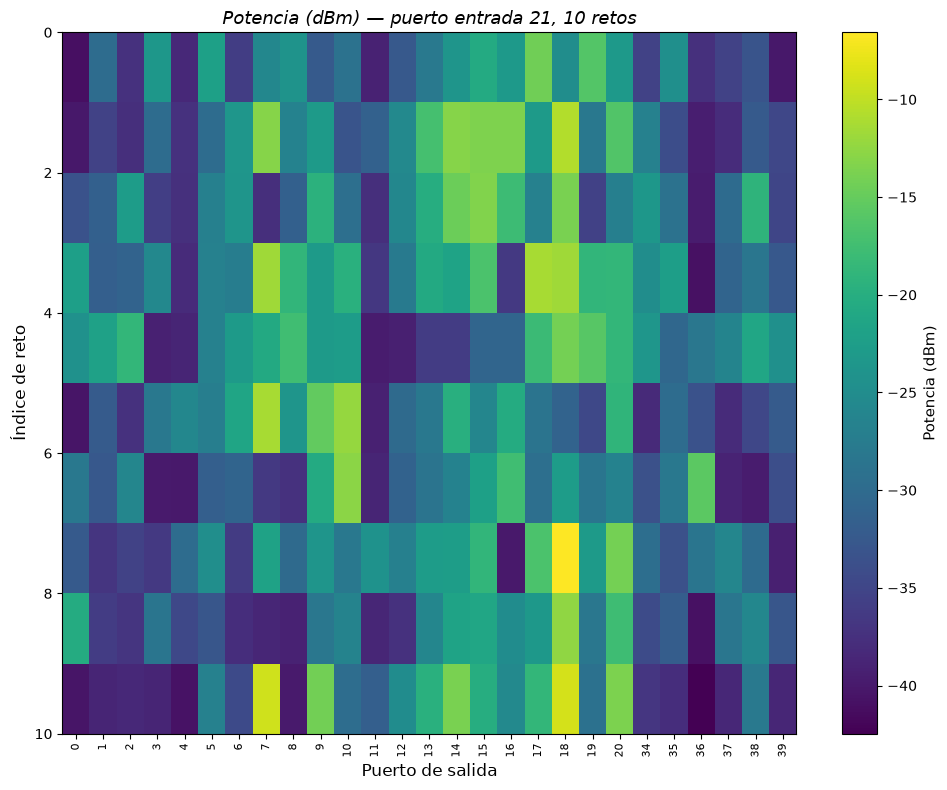

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

with open('powers_base_1550nm_port21.json') as f:
    data = json.load(f)

print(f"Puerto de entrada: {data['inport']}")
print(f"Puertos de salida: {data['outports']}")
print(f"Retos medidos:     {data['n_medidos']}")

# ── Construir matriz: filas = retos, columnas = puertos de salida ──────
df = pd.DataFrame(data['powers'])
df.columns = [int(c) for c in df.columns]
df = df[sorted(df.columns)]

print(f"\nShape de la matriz: {df.shape}  (retos x puertos de salida)")

# ── PLOT: heatmap retos x puertos ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(df.values, aspect='auto', cmap='viridis',
               extent=[0, len(df.columns), len(df), 0])

ax.set_xticks(np.arange(len(df.columns)) + 0.5)
ax.set_xticklabels(df.columns, rotation=90, fontsize=8)
ax.set_xlabel('Puerto de salida', fontsize=12)
ax.set_ylabel('Índice de reto', fontsize=12)
ax.set_title(f'Potencia (dBm) — puerto entrada {data["inport"]}, '
             f'{data["n_medidos"]} retos', fontsize=13, fontstyle='italic')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Potencia (dBm)', fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
# ── RECORRIDO AUTOMÁTICO POR PUERTOS ───────────────────────────────────
import glob, re

PUERTOS_A_MEDIR = ACTIVE_PORTS   # o una lista concreta, ej. [21, 22, 23]

# Repoblar PUERTOS_HECHOS mirando qué archivos ya existen en disco
# (útil si reinicias el kernel a mitad de sesión)
PUERTOS_HECHOS = []
for fname in glob.glob('powers_base_1550nm_port*.json'):
    m = re.search(r'port(\d+)\.json$', fname)
    if m:
        PUERTOS_HECHOS.append(int(m.group(1)))
PUERTOS_HECHOS = sorted(set(PUERTOS_HECHOS))

if PUERTOS_HECHOS:
    print(f'✓ Puertos ya medidos (detectados en disco): {PUERTOS_HECHOS}')
else:
    print('No hay puertos medidos todavía — empezando de cero')

for puerto in PUERTOS_A_MEDIR:
    if puerto in PUERTOS_HECHOS:
        continue

    print(f'\n{"="*50}\nPUERTO {puerto}\n{"="*50}')
    input(f'Conecta la fibra al puerto {puerto} y pulsa Enter...')

    # Puerto de salida para polarización — normalmente el mismo, pero
    # cambiable puerto a puerto si hace falta (Enter = mantener el de antes)
    _outport_str = input(f'Puerto de salida para polarización (Enter = {PRUEBA_OUTPORT}): ').strip()
    outport_actual = int(_outport_str) if _outport_str else PRUEBA_OUTPORT

    # 1. Preparar modo externo y ajustar polarización a mano
    preparar_externo(puerto, outport_actual)
    input('Ajusta la polarización con el medidor analógico y pulsa Enter...')

    # 2. Comprobar con fotodetectores internos
    comprobar_polarizacion(puerto, outport_actual)
    continuar = input('¿Polarización OK? (Enter para continuar, "r" para repetir el puerto) ')
    if continuar.strip().lower() == 'r':
        continue   # repite el mismo puerto sin marcarlo como hecho

    # 3. Medida estándar a 1550nm (500 retos)
    print(f'Midiendo {N_RETOS_BASE} retos a {WL_BASE} nm...')
    res_base = medir_remoto(inport=puerto, n_retos=N_RETOS_BASE)

    if 'error' in res_base:
        print(f'⚠ Error en medida base puerto {puerto}: {res_base["error"]}')
        continue   # no marca el puerto como hecho, lo reintentará otro día

    fname_base = f'powers_base_1550nm_port{puerto:02d}.json'
    with open(fname_base, 'w') as f:
        json.dump(res_base, f, indent=2)
    print(f'✓ Medida base guardada — {res_base["n_medidos"]} retos → {fname_base}')

    # 4. Barrido de longitud de onda
    resultados_barrido = []
    for wl in WAVELENGTHS:
        laser.wl = float(wl)
        laser.set_wl_laser()
        time.sleep(0.5)

        res = medir_remoto(inport=puerto, n_retos=N_RETOS_BARRIDO)
        if 'error' in res:
            print(f'⚠ λ={wl:.2f} nm → {res["error"]}')
            continue

        resultados_barrido.append({'wavelength': float(wl), 'powers': res['powers']})
        print(f'λ={wl:.2f} nm  →  {res["n_medidos"]} retos medidos')

    fname_barrido = f'barrido_lambda_port{puerto:02d}.json'
    with open(fname_barrido, 'w') as f:
        json.dump(resultados_barrido, f, indent=2)
    print(f'✓ {len(resultados_barrido)} puntos de λ guardados → {fname_barrido}')

    # 5. Marcar puerto como hecho
    PUERTOS_HECHOS.append(puerto)
    print(f'\n✓✓ Puerto {puerto} completado ({len(PUERTOS_HECHOS)}/{len(PUERTOS_A_MEDIR)})')

print(f'\n{"="*50}\nSESIÓN COMPLETA — {len(PUERTOS_HECHOS)} puertos medidos\n{"="*50}')
print(f'Puertos hechos:      {PUERTOS_HECHOS}')
print(f'Puertos pendientes:  {[p for p in PUERTOS_A_MEDIR if p not in PUERTOS_HECHOS]}')

## Sección 7 — Cierre limpio
Ejecutar **siempre al terminar**, aunque haya habido errores.

In [3]:
try:
    keithley.off_keithley_volt()
    print('✓ Keithley apagado')
except Exception as e:
    print(f'Keithley ya apagado o no conectado: {e}')

try:
    laser.off_laser()
    print('✓ Láser apagado')
except Exception as e:
    print(f'Láser ya apagado o no conectado: {e}')

try:
    stdin.write('EXIT\n')
    stdin.flush()
    ssh.close()
    print('✓ SmartLight desconectado, SSH cerrado')
except Exception as e:
    print(f'SSH ya cerrado: {e}')

Keithley ya apagado o no conectado: name 'keithley' is not defined
Láser ya apagado o no conectado: name 'laser' is not defined
SSH ya cerrado: name 'stdin' is not defined


## Sección 8 — Guardar resultados
Ejecutar tras la Sección 5 (Keithley) y/o Sección 6 (láser).

In [ ]:
# Resultados del barrido de voltaje (Keithley)
if 'resultados_keithley' in dir() and resultados_keithley:
    with open('barrido_voltaje_chip.json', 'w') as f:
        json.dump(resultados_keithley, f, indent=2)

    df_resumen = pd.DataFrame([
        {'voltaje_programado': r['voltaje_programado'],
         'voltaje_medido':     r['voltaje_medido'],
         'corriente_mA':       r['corriente_mA'],
         'n_retos':            len(r['powers'])}
        for r in resultados_keithley
    ])
    df_resumen.to_csv('barrido_voltaje_resumen.csv', index=False)
    print(f'✓ {len(resultados_keithley)} puntos de voltaje guardados')
    print(df_resumen)

In [ ]:
# Resultados del barrido de longitud de onda (láser)
if 'resultados_barrido' in dir() and resultados_barrido:
    with open(f'barrido_lambda_port{INPORT_LASER:02d}.json', 'w') as f:
        json.dump(resultados_barrido, f, indent=2)
    print(f'✓ {len(resultados_barrido)} puntos de λ guardados')